<a href="https://colab.research.google.com/github/dataguirre/curso-ia-ciencia-de-datos/blob/main/workshops/06-pipeline-tiquetes-vlm-local.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline de tiquetes de báscula con un VLM local

Notebook **independiente**: no necesita Groq ni conexión a ninguna API. Toma una carpeta con fotos de
tiquetes, las procesa con un modelo de visión y lenguaje que corre en la GPU de Colab, y escribe un CSV.

```text
carpeta de fotos → VLM local → JSON → normalizar → validar ─┬─ OK       → CSV
                                                            └─ revisar  → CSV (marcado)
```

> **Necesitas GPU.** `Entorno de ejecución > Cambiar tipo de entorno de ejecución > T4 GPU`.
> Sin GPU el modelo tarda varios minutos por foto.

**Cómo usarlo:**
1. Sube un `.zip` con tus fotos arrastrándolo al panel de archivos de la izquierda (o descomenta las
   dos líneas del paso 6 para subirlo con un botón). También sirve una carpeta suelta.
2. Ajusta `ENTRADA` en la celda de configuración.
3. `Entorno de ejecución > Ejecutar todas`.

## 1. Instalación e imports

In [ ]:
!pip install -q -U transformers accelerate

import json
import re
import shutil
import time
import zipfile
from datetime import datetime
from pathlib import Path

import pandas as pd
import torch
from PIL import Image
from transformers import AutoModelForImageTextToText, AutoProcessor

print("✓ torch", torch.__version__)
print("✓ GPU disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("  ", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 23.3 MB/s eta 0:00:00
✓ torch 2.11.0+cu128
✓ GPU disponible: True
   Tesla T4


## 2. Configuración

Lo único que normalmente hay que tocar está en esta celda.

In [ ]:
# ---- Lo que cambias tú ----
ENTRADA         = "mis_tiquetes.zip"        # archivo .zip con las fotos (o una carpeta)
CARPETA_TRABAJO = "fotos_tiquetes"          # donde se descomprime el .zip
CSV_SALIDA      = "tiquetes_extraidos.csv"  # archivo de salida
MODELO_LOCAL    = "Qwen/Qwen3-VL-2B-Instruct"   # alternativa: "Qwen/Qwen2.5-VL-3B-Instruct"

# ---- Parámetros del modelo ----
LADO_MAXIMO     = 1280   # píxeles del lado mayor de la imagen que se envía
MAX_NEW_TOKENS  = 900    # tokens que puede generar; el JSON completo ocupa ~500
INTENTOS_JSON   = 2      # reintentos si la respuesta no es JSON válido

# ---- Archivos de trabajo ----
CACHE           = "cache_local.json"   # respuestas crudas, para no repetir trabajo
EXTENSIONES     = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"}

# ---- Esquema del tiquete ----
CAMPOS_TEXTO    = ["tiquete", "conductor", "cedula", "vehiculo", "nit_proveedor", "pto_descargue"]
CAMPOS_ENTEROS  = ["remision", "ciclo", "racimos", "peso_bruto", "tara", "peso_neto", "muestra"]
CAMPOS_FECHA    = ["fecha_entrada", "fecha_salida"]
CRITERIOS       = ["maduro", "verde", "sobremaduro", "podrido", "pedunculo", "enfermo", "malformado"]
CAMPOS_CALIDAD  = [f"{c}_{s}" for c in CRITERIOS for s in ("n", "pct")]
CAMPOS          = CAMPOS_TEXTO + CAMPOS_FECHA + CAMPOS_ENTEROS + CAMPOS_CALIDAD

print(f"✓ {len(CAMPOS)} campos por tiquete")

✓ 29 campos por tiquete


## 3. Cargar el modelo

La primera vez descarga unos 4 GB de pesos, así que tarda un par de minutos. Queda en memoria hasta que
reinicies la sesión: si vuelves a correr el pipeline no hay que repetirlo.

In [ ]:
if not torch.cuda.is_available():
    raise RuntimeError(
        "Este notebook necesita GPU. Ve a Entorno de ejecución > Cambiar tipo de entorno de ejecución > T4 GPU."
    )

processor = AutoProcessor.from_pretrained(MODELO_LOCAL)
modelo_local = AutoModelForImageTextToText.from_pretrained(
    MODELO_LOCAL, dtype=torch.float16, device_map="cuda"
)
modelo_local.eval()

print(f"✓ {MODELO_LOCAL} cargado")
print(f"  Memoria usada: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/5.50k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/10.9k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 4.26GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

✓ Qwen/Qwen3-VL-2B-Instruct cargado
  Memoria usada: 4.3 GB


## 4. El prompt y la extracción

El prompt es el mismo de la versión con API: le pedimos al modelo que **copie los valores tal como
aparecen impresos** (`"32.280 Kg"`, `"88,10 %"`). La conversión a números la hace Python en el paso
siguiente, donde no hay riesgo de que el modelo se equivoque en la aritmética.

In [ ]:
PROMPT_EXTRACCION = """Eres un sistema que transcribe tiquetes de báscula de una planta extractora de palma.
Devuelve SOLO un objeto JSON con exactamente estas claves. Copia cada valor tal como aparece impreso,
con sus puntos, comas, "%" y "Kg". Si un campo está vacío en el tiquete, usa "".

{
  "tiquete": "", "remision": "",
  "fecha_entrada": "", "fecha_salida": "",
  "conductor": "", "cedula": "", "vehiculo": "", "nit_proveedor": "",
  "ciclo": "", "racimos": "", "pto_descargue": "",
  "peso_bruto": "", "tara": "", "peso_neto": "",
  "muestra": "",
  "calidad": {
    "maduro": {"evaluacion": "", "promedio": ""},
    "verde": {"evaluacion": "", "promedio": ""},
    "sobremaduro": {"evaluacion": "", "promedio": ""},
    "podrido": {"evaluacion": "", "promedio": ""},
    "pedunculo": {"evaluacion": "", "promedio": ""},
    "enfermo": {"evaluacion": "", "promedio": ""},
    "malformado": {"evaluacion": "", "promedio": ""}
  }
}

En la tabla EVALUACION DE CALIDAD: RACIMO MADUR = maduro, RACIMO VERDE = verde,
RACIMO SOBRE = sobremaduro, RACIMO PODRID = podrido, RACIMO PEDÚN = pedunculo,
RACIMO ENFER = enfermo y RACIMO MALFO = malformado.
En "muestra" copia solo el número que aparece después de "Muestra:"."""


def parsear_json(texto: str) -> dict:
    """Extrae y lee el objeto JSON contenido en un texto."""
    inicio = texto.find("{")
    fin = texto.rfind("}")
    if inicio == -1 or fin == -1 or fin < inicio:
        raise ValueError(f"No se encontró un objeto JSON en: {texto[:100]!r}")
    return json.loads(texto[inicio:fin + 1])


def generar(ruta, lado_maximo=LADO_MAXIMO, max_new_tokens=MAX_NEW_TOKENS) -> str:
    """Le pasa una imagen al VLM local y devuelve el texto que genera."""
    imagen = Image.open(ruta).convert("RGB")
    imagen.thumbnail((lado_maximo, lado_maximo))
    mensajes = [{"role": "user", "content": [
        {"type": "image", "image": imagen},
        {"type": "text", "text": PROMPT_EXTRACCION},
    ]}]
    entradas = processor.apply_chat_template(
        mensajes, tokenize=True, add_generation_prompt=True, return_dict=True, return_tensors="pt"
    ).to(modelo_local.device)
    with torch.inference_mode():
        salida = modelo_local.generate(**entradas, max_new_tokens=max_new_tokens, do_sample=False)
    return processor.decode(salida[0, entradas["input_ids"].shape[1]:], skip_special_tokens=True)


def extraer_tiquete_local(ruta, intentos=INTENTOS_JSON) -> dict:
    """Extrae los campos de un tiquete con el VLM local, reintentando si el JSON sale mal."""
    ultimo_error = None
    for intento in range(intentos):
        texto = generar(ruta)
        try:
            return parsear_json(texto)
        except ValueError as e:
            ultimo_error = e
            if intento + 1 < intentos:
                print(f"    (JSON inválido, reintento {intento + 2}/{intentos})")
    raise ValueError(f"El modelo no devolvió un JSON válido tras {intentos} intentos: {ultimo_error}")


print("✓ Funciones de extracción listas")

✓ Funciones de extracción listas


## 5. Normalizar y validar

El modelo transcribe; el código convierte. Así cada error queda en un lugar identificable: si un peso sale
mal, o el modelo lo leyó mal o la conversión falló, pero nunca las dos cosas mezcladas.

Las reglas de validación salen del propio tiquete, así que funcionan **sin** tener la respuesta correcta:
los pesos deben cuadrar, los porcentajes deben corresponder a los conteos sobre la muestra, los cuatro
estados de madurez deben sumar la muestra y la salida debe ser posterior a la entrada.

In [ ]:
def normalizar_numero_co(texto) -> int:
    """Convierte un entero impreso en formato colombiano ("32.280 Kg") a int."""
    texto = str(texto)
    if "," in texto:
        raise ValueError(f"{texto!r} tiene coma decimal: no es un entero")
    digitos = re.sub(r"\D", "", texto)
    if not digitos:
        raise ValueError(f"{texto!r} no contiene dígitos")
    return int(digitos)


def normalizar_porcentaje(texto) -> float:
    """Convierte un porcentaje impreso ("88,10 %") a float."""
    texto = str(texto).replace("%", "").replace(" ", "")
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    return float(texto)


def normalizar_fecha(texto) -> str:
    """Convierte "12-08-2026 19:12:57" en "2026-08-12 19:12:57"."""
    fecha = datetime.strptime(str(texto).strip(), "%d-%m-%Y %H:%M:%S")
    return fecha.strftime("%Y-%m-%d %H:%M:%S")


def _seguro(funcion, valor):
    try:
        return funcion(valor)
    except (ValueError, TypeError, AttributeError):
        return None


def normalizar_tiquete(crudo: dict) -> dict:
    """Convierte la respuesta del VLM en una fila con valores normalizados."""
    fila = {c: str(crudo.get(c) or "").strip().upper() for c in CAMPOS_TEXTO}
    fila.update({c: _seguro(normalizar_fecha, crudo.get(c)) for c in CAMPOS_FECHA})
    fila.update({c: _seguro(normalizar_numero_co, crudo.get(c)) for c in CAMPOS_ENTEROS})
    calidad = crudo.get("calidad") or {}
    for criterio in CRITERIOS:
        valores = calidad.get(criterio) or {}
        fila[f"{criterio}_n"] = _seguro(normalizar_numero_co, valores.get("evaluacion"))
        fila[f"{criterio}_pct"] = _seguro(normalizar_porcentaje, valores.get("promedio"))
    return fila


def validar_tiquete(t: dict) -> list:
    """Revisa un tiquete normalizado con las reglas del documento."""
    problemas = [f"falta {c}" for c in CAMPOS_FECHA + CAMPOS_ENTEROS + CAMPOS_CALIDAD if t.get(c) is None]

    bruto, tara, neto = t.get("peso_bruto"), t.get("tara"), t.get("peso_neto")
    if bruto is not None and tara is not None and neto is not None and bruto - tara != neto:
        problemas.append(f"pesos: {bruto} - {tara} = {bruto - tara}, pero peso_neto dice {neto}")

    muestra = t.get("muestra")
    if muestra == 0:
        problemas.append("muestra en cero")
    elif muestra is not None:
        for criterio in CRITERIOS:
            n, pct = t.get(f"{criterio}_n"), t.get(f"{criterio}_pct")
            if n is None or pct is None:
                continue
            esperado = round(100 * n / muestra, 2)
            if abs(esperado - pct) > 0.01:
                problemas.append(f"porcentaje {criterio}: {n}/{muestra} da {esperado}, pero dice {pct}")

        madurez = [t.get(f"{c}_n") for c in ("maduro", "verde", "sobremaduro", "podrido")]
        if all(v is not None for v in madurez) and sum(madurez) != muestra:
            problemas.append(f"madurez: suman {sum(madurez)}, pero la muestra es {muestra}")

    entrada, salida = t.get("fecha_entrada"), t.get("fecha_salida")
    if entrada is not None and salida is not None and salida <= entrada:
        problemas.append(f"tiempos: salida {salida} no es posterior a entrada {entrada}")

    return problemas


print("✓ Funciones de normalización y validación listas")

✓ Funciones de normalización y validación listas


## 6. Abrir el .zip

`preparar_entrada` acepta las dos cosas: un `.zip`, que descomprime en `CARPETA_TRABAJO`, o una carpeta que
ya esté en el disco. Busca las imágenes en todos los subdirectorios, así que no importa si el zip trae las
fotos sueltas o dentro de una carpeta.

In [ ]:
def preparar_entrada(entrada=None, carpeta_trabajo=None) -> list:
    """Acepta un .zip o una carpeta y devuelve la lista de imágenes que contiene."""
    entrada = Path(entrada or ENTRADA)
    carpeta_trabajo = Path(carpeta_trabajo or CARPETA_TRABAJO)

    if entrada.suffix.lower() == ".zip":
        if not entrada.is_file():
            raise FileNotFoundError(
                f"No existe el archivo {str(entrada)!r}. "
                "Súbelo al panel de archivos de Colab y revisa ENTRADA."
            )
        if not zipfile.is_zipfile(entrada):
            raise ValueError(f"{str(entrada)!r} no es un .zip válido (¿se subió completo?)")
        if carpeta_trabajo.exists():
            shutil.rmtree(carpeta_trabajo)       # empezar limpio: manda el zip
        with zipfile.ZipFile(entrada) as z:
            z.extractall(carpeta_trabajo)
        print(f"✓ {entrada.name} descomprimido en {carpeta_trabajo}/")
        carpeta = carpeta_trabajo
    elif entrada.is_dir():
        carpeta = entrada
    else:
        raise FileNotFoundError(f"{str(entrada)!r} no es un .zip ni una carpeta existente")

    imagenes = sorted(
        p for p in carpeta.rglob("*")
        if p.suffix.lower() in EXTENSIONES
        and not p.name.startswith(".")           # ._foto.jpg de macOS
        and "__MACOSX" not in p.parts            # carpeta de metadatos de macOS
    )
    if not imagenes:
        encontradas = sorted({p.suffix.lower() for p in carpeta.rglob("*") if p.suffix})
        raise FileNotFoundError(
            f"No hay imágenes en {str(carpeta)!r}. "
            f"Extensiones aceptadas: {sorted(EXTENSIONES)}. Encontradas: {encontradas or 'ninguna'}"
        )
    return imagenes


# Descomenta para subir el .zip desde tu computador en vez de arrastrarlo al panel de archivos:
# from google.colab import files
# ENTRADA = next(iter(files.upload()))

imagenes = preparar_entrada()
print(f"✓ {len(imagenes)} imágenes: {', '.join(p.name for p in imagenes[:5])}"
      + (f" … (+{len(imagenes) - 5} más)" if len(imagenes) > 5 else ""))

✓ mis_tiquetes.zip descomprimido en fotos_tiquetes/
✓ 15 imágenes: tiquete_01.jpg, tiquete_02.jpg, tiquete_03.jpg, tiquete_04.jpg, tiquete_05.jpg … (+10 más)


## 7. Prueba con una sola foto

Antes de lanzar la carpeta completa, conviene ver una foto y comparar el resultado con lo que está impreso.
Si el modelo no acierta aquí, no tiene sentido esperar a que procese cincuenta.

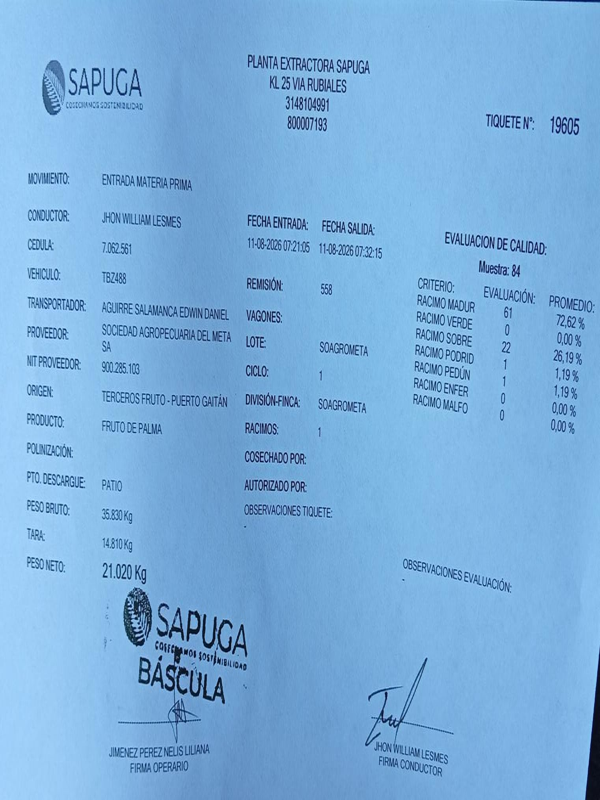


tiquete_01.jpg en 32 s

{
  "tiquete": "19605",
  "remision": "558",
  "fecha_entrada": "11-08-2026 07:21:05",
  "fecha_salida": "11-08-2026 07:32:15",
  "conductor": "JHON WILLIAM LESMES",
  "cedula": "7.062.561",
  "vehiculo": "TBZ488",
  "nit_proveedor": "900.285.103",
  "ciclo": "1",
  "racimos": "1",
  "pto_descargue": "PATIO",
  "peso_bruto": "35.830 Kg",
  "tara": "14.810 Kg",
  "peso_neto": "21.020 Kg",
  "muestra": "84",
  "calidad": {
    "maduro": {
      "evaluacion": "61",
      "promedio": "72,62 %"
    },
    "verde": {
      "evaluacion": "0",
      "promedio": "0,00 %"
    },
    "sobremaduro": {
      "evaluacion": "22",
      "promedio": "26,19 %"
    },
    "podrido": {
      "evaluacion": "1",
      "promedio": "1,19 %"
    },
    "pedunculo": {
      "evaluacion": "1",
      "promedio": "1,19 %"
    },
    "enfermo": {
      "evaluacion": "0",
      "promedio": "0,00 %"
    },
    "malformado": {
      "evaluacion": "0",
      "promedio": "0,00 %"
    }
  }
}

Va

In [ ]:
muestra_ruta = imagenes[0]
display(Image.open(muestra_ruta).copy().resize((600, 800)))

inicio = time.time()
crudo_ejemplo = extraer_tiquete_local(muestra_ruta)
print(f"\n{muestra_ruta.name} en {time.time() - inicio:.0f} s\n")
print(json.dumps(crudo_ejemplo, ensure_ascii=False, indent=2))

fila_ejemplo = normalizar_tiquete(crudo_ejemplo)
problemas_ejemplo = validar_tiquete(fila_ejemplo)
print("\nValidación:", problemas_ejemplo if problemas_ejemplo else "sin problemas ✓")

## 8. El pipeline completo

Procesa todas las fotos del `.zip` y escribe el CSV. Guarda cada respuesta en `cache_local.json` apenas la obtiene,
así que si la sesión se cae solo pierdes la foto en curso: vuelve a correr la celda y sigue donde iba.

In [ ]:
def procesar_carpeta(entrada=None, csv_salida=CSV_SALIDA, cache=CACHE):
    """Extrae, normaliza y valida todas las fotos de un .zip o una carpeta; devuelve un DataFrame."""
    imagenes = preparar_entrada(entrada)
    ruta_cache = Path(cache)
    crudos = json.loads(ruta_cache.read_text()) if ruta_cache.exists() else {}

    # --- 1. Extracción con el VLM local ---
    pendientes = [p for p in imagenes if p.name not in crudos]
    if pendientes:
        print(f"Procesando {len(pendientes)} imágenes ({len(imagenes) - len(pendientes)} ya en caché)\n")
    else:
        print("Todo estaba en caché, no se ejecutó el modelo.\n")

    for i, ruta in enumerate(pendientes, 1):
        inicio = time.time()
        try:
            crudos[ruta.name] = {"crudo": extraer_tiquete_local(ruta), "error": None}
        except Exception as e:
            crudos[ruta.name] = {"crudo": {}, "error": f"{type(e).__name__}: {e}"}
        crudos[ruta.name]["segundos"] = round(time.time() - inicio, 1)
        ruta_cache.write_text(json.dumps(crudos, ensure_ascii=False, indent=1))

        estado = crudos[ruta.name]["error"] or "ok"
        print(f"[{i}/{len(pendientes)}] {ruta.name}: {estado} ({crudos[ruta.name]['segundos']} s)")

    # --- 2. Normalización y validación ---
    filas = []
    for ruta in imagenes:
        registro = crudos[ruta.name]
        fila = normalizar_tiquete(registro["crudo"])
        problemas = ["error de extracción"] if registro["error"] else validar_tiquete(fila)
        filas.append({
            "archivo": ruta.name,
            **{c: fila.get(c) for c in CAMPOS},
            "requiere_revision": bool(problemas),
            "problemas": "; ".join(problemas),
            "error": registro["error"] or "",
            "segundos": registro["segundos"],
        })

    df = pd.DataFrame(filas)

    # Enteros nullable: evita que un solo None convierta la columna en 17090.0
    for columna in CAMPOS_ENTEROS + [c for c in CAMPOS_CALIDAD if c.endswith("_n")]:
        df[columna] = pd.array(df[columna], dtype="Int64")

    df.to_csv(csv_salida, index=False, encoding="utf-8-sig")

    listos = int((~df["requiere_revision"]).sum())
    print(f"\n{'─' * 60}")
    print(f"✓ {csv_salida}  ({len(df)} filas)")
    print(f"  Cargables automáticamente: {listos} de {len(df)}")
    print(f"  Para revisión humana:      {len(df) - listos}")
    print(f"  Tiempo medio por foto:     {df['segundos'].mean():.0f} s")
    for _, f in df[df["requiere_revision"]].iterrows():
        print(f"    • {f['archivo']}: {f['problemas'][:90]}")
    return df


resultado = procesar_carpeta()
display(resultado.head())

✓ mis_tiquetes.zip descomprimido en fotos_tiquetes/
Procesando 15 imágenes (0 ya en caché)

[1/15] tiquete_01.jpg: ok (23.9 s)
[2/15] tiquete_02.jpg: ok (22.1 s)
[3/15] tiquete_03.jpg: ok (27.6 s)
[4/15] tiquete_04.jpg: ok (27.0 s)
[5/15] tiquete_05.jpg: ok (21.6 s)
[6/15] tiquete_06.jpg: ok (21.9 s)
[7/15] tiquete_07.jpg: ok (21.5 s)
[8/15] tiquete_08.jpg: ok (21.1 s)
[9/15] tiquete_09.jpg: ok (21.8 s)
[10/15] tiquete_10.jpg: ok (21.6 s)
[11/15] tiquete_11.jpg: ok (21.1 s)
[12/15] tiquete_12.jpg: ok (21.7 s)
[13/15] tiquete_13.jpg: ok (21.9 s)
[14/15] tiquete_14.jpg: ok (22.0 s)
[15/15] tiquete_15.jpg: ok (21.7 s)

────────────────────────────────────────────────────────────
✓ tiquetes_extraidos.csv  (15 filas)
  Cargables automáticamente: 14 de 15
  Para revisión humana:      1
  Tiempo medio por foto:     23 s
    • tiquete_05.jpg: porcentaje podrido: 4/84 da 4.76, pero dice 4.78


,archivo,tiquete,conductor,cedula,vehiculo,nit_proveedor,pto_descargue,fecha_entrada,fecha_salida,remision,...,pedunculo_n,pedunculo_pct,enfermo_n,enfermo_pct,malformado_n,malformado_pct,requiere_revision,problemas,error,segundos
0,tiquete_01.jpg,19605,JHON WILLIAM LESMES,7.062.561,TBZ488,900.285.103,PATIO,2026-08-11 07:21:05,2026-08-11 07:32:15,558,...,1,1.19,0,0.0,0,0.0,False,,,23.9
1,tiquete_02.jpg,19666,JHON WILLIAM LESMES,7.062.561,TBZ488,900.285.103,32.280 KG,2026-08-12 19:12:57,2026-08-12 19:24:36,559,...,2,2.38,0,0.0,0,0.0,False,,,22.1
2,tiquete_03.jpg,19722,JHON WILLIAM LESMES,7.062.561,TBZ488,900.285.103,,2026-08-14 12:36:14,2026-08-14 12:47:27,561,...,0,0.00,0,0.0,0,0.0,False,,,27.6
3,tiquete_04.jpg,19746,JHON WILLIAM LESMES,7.062.561,TBZ488,900.285.103,TERCEROS FRUTO - PUERTO GAITÁN,2026-08-15 08:20:19,2026-08-15 08:30:21,562,...,2,2.38,0,0.0,0,0.0,False,,,27.0
4,tiquete_05.jpg,19777,JHON WILLIAM LESMES,7.062.561,TBZ488,900.285.103,31.530 KG,2026-08-17 10:51:01,2026-08-17 11:00:24,563,...,2,2.38,0,0.0,0,0.0,True,"porcentaje podrido: 4/84 da 4.76, pero dice 4.78",,21.6


## 9. Revisar y descargar

In [ ]:
# Las filas que necesitan un par de ojos humanos
revisar = resultado[resultado["requiere_revision"]]
display(revisar[["archivo", "tiquete", "peso_neto", "problemas"]] if len(revisar) else "Ninguna 🎉")

# Qué reglas fallan más (útil para saber dónde flojea el modelo)
if len(revisar):
    conteo = (revisar["problemas"].str.split("; ").explode()
              .str.split(":").str[0].value_counts())
    display(conteo.rename("veces").to_frame())

,archivo,tiquete,peso_neto,problemas
4,tiquete_05.jpg,19777,16340,"porcentaje podrido: 4/84 da 4.76, pero dice 4.78"


,veces
problemas,
porcentaje podrido,1


In [ ]:
from google.colab import files
files.download(CSV_SALIDA)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notas

**El modelo local es más pequeño que uno de API.** Unos 2.000 millones de parámetros frente a decenas de
miles de millones. Espera menos exactitud, sobre todo en la tabla de calidad, que tiene letra pequeña. La
ventaja es que los datos de los conductores (nombre y cédula) nunca salen de la máquina, y no hay límites
de uso ni costo por foto.

**Si el JSON sale mal a menudo**, prueba en este orden: subir `MAX_NEW_TOKENS` (puede estar cortando la
respuesta a media llave), subir `LADO_MAXIMO` a 1600, o cambiar a `Qwen/Qwen2.5-VL-3B-Instruct`.

**Si la GPU se queda sin memoria** (`CUDA out of memory`), baja `LADO_MAXIMO` a 1024. Una imagen más grande
se convierte en muchos más tokens visuales.

**`requiere_revision` no atrapa todo.** Las reglas comparan campos entre sí, así que detectan un peso o un
porcentaje mal leídos. Pero un número de tiquete o una cédula equivocados pasan sin marca: no hay nada más
en el documento con qué contrastarlos. Un campo vacío se nota; un campo incorrecto no.

**La caché va por nombre de archivo.** Si subes un zip nuevo con fotos distintas, se acumulan sin problema.
Pero si cambias una foto conservando su nombre, o quieres reprocesar todo desde cero, borra la caché:

```python
!rm cache_local.json
```